# Comparative Analysis of Resume-JD Matching Algorithms

This notebook compares the rankings and similarity scores produced by three different algorithms for matching resumes to job descriptions (JD):

- **Cosine Similarity** (from Resume Classification ML)
- **Jaccard Similarity** (from Resume Classification ML)
- **Siamese Network Similarity** (from Siamese Network Matching)

We will load the results, align the candidates, and visualize the agreement and differences between the methods.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau
plt.style.use('seaborn-v0_8-darkgrid')

## Load Results from All Algorithms
We load the outputs from the Cosine/Jaccard (classification ML) and Siamese network matching.

In [2]:
# Load Cosine/Jaccard results
ml_df = pd.read_csv('../data/results/combined_ranking_comparison.csv')
# Load Siamese network results
siamese_df = pd.read_csv('../data/results/siamese_ranking_results.csv')

# Preview
display(ml_df.head(3))
display(siamese_df.head(3))

,Resume_ID,Candidate_Name,Cosine_Rank,Cosine_Score,Cosine_Percentage,Rank_Jaccard,Jaccard_Score,Jaccard_Percentage,Rank_Difference,Score_Difference,Category,Key_Skills,Rank_Agreement
0,694,Candidate_694,1,0.639658,63.970001,114,0.031847,3.18,-113,0.607811,🌟 Excellent Match,year bootstrap expressjs year ajax year year a...,🔴 Large (>10)
1,859,Candidate_859,2,0.639658,63.970001,113,0.031847,3.18,-111,0.607811,🌟 Excellent Match,year bootstrap expressjs year ajax year year a...,🔴 Large (>10)
2,638,Candidate_638,3,0.639658,63.970001,112,0.031847,3.18,-109,0.607811,🌟 Excellent Match,year bootstrap expressjs year ajax year year a...,🔴 Large (>10)


,Resume_str,similarity_score
0,"BQN ? ? extensive ms office tools (word, exce...",0.924029
1,AFY front end developer goldenraytech may 2018...,0.911410
2,XL front end developer goldenraytech may 2018 ...,0.911107


In [4]:
# Generate mapping between numeric and Excel-like IDs using parsed_resumes.csv
def excel_col(n):
    """Convert 0-based index to Excel-like column label (A, B, ..., Z, AA, AB, ...)"""
    label = ''
    while n >= 0:
        label = chr(n % 26 + 65) + label
        n = n // 26 - 1
    return label
parsed_df = pd.read_csv('../data/raw/parsed_resumes.csv')
parsed_df = parsed_df.reset_index(drop=True)
parsed_df['Numeric_ID'] = parsed_df.index + 1
parsed_df['Excel_ID'] = [excel_col(i) for i in range(len(parsed_df))]
mapping_df = parsed_df[['Numeric_ID', 'Excel_ID', 'Person Name']]
print('Sample mapping:')
display(mapping_df.head(20))

Sample mapping:


,Numeric_ID,Excel_ID,Person Name
0,1,A,A
1,2,B,B
2,3,C,C
3,4,D,D
4,5,E,E
5,6,F,F
6,7,G,G
7,8,H,H
8,9,I,I
9,10,J,J


In [6]:
# Robust merge using mapping between numeric and Excel-like IDs
ml_df = ml_df.copy()
siamese_df = siamese_df.copy()
parsed_df = parsed_df.copy()
ml_df['Numeric_ID'] = ml_df['Resume_ID'].astype(int) if 'Resume_ID' in ml_df.columns else ml_df.index + 1
siamese_df['Excel_ID'] = siamese_df['Resume_str'].str.extract(r'^([A-Z]+)')[0]
mapping_df = parsed_df[['Numeric_ID', 'Excel_ID']]
# Merge mapping to both dataframes
ml_df = pd.merge(ml_df, mapping_df, on='Numeric_ID', how='left')
siamese_df = pd.merge(siamese_df, mapping_df, on='Excel_ID', how='left')
# Now merge on Numeric_ID (the unified unique ID)
merged = pd.merge(ml_df, siamese_df, on='Numeric_ID', suffixes=('_ml', '_siamese'))
print(f'Merged shape: {merged.shape}')
display(merged[['Candidate_Name', 'Cosine_Rank', 'Rank_Jaccard', 'similarity_score']].head(5))

Merged shape: (2436, 21)


,Candidate_Name,Cosine_Rank,Rank_Jaccard,similarity_score
0,Candidate_694,1,114,0.896963
1,Candidate_859,2,113,0.896155
2,Candidate_638,3,112,0.896411
3,Candidate_749,4,181,0.855879
4,Candidate_716,5,33,0.877292


## Correlation Analysis
We compare the rankings and similarity scores between the three algorithms.

In [7]:
# Calculate correlations
corr_cosine_siamese = spearmanr(merged['Cosine_Rank'], merged['similarity_score'])
corr_jaccard_siamese = spearmanr(merged['Rank_Jaccard'], merged['similarity_score'])
corr_cosine_jaccard = spearmanr(merged['Cosine_Rank'], merged['Rank_Jaccard'])
print(f'Spearman Correlation (Cosine Rank vs Siamese Score): {corr_cosine_siamese.correlation:.3f}')
print(f'Spearman Correlation (Jaccard Rank vs Siamese Score): {corr_jaccard_siamese.correlation:.3f}')
print(f'Spearman Correlation (Cosine Rank vs Jaccard Rank): {corr_cosine_jaccard.correlation:.3f}')

Spearman Correlation (Cosine Rank vs Siamese Score): -0.336
Spearman Correlation (Jaccard Rank vs Siamese Score): -0.374
Spearman Correlation (Cosine Rank vs Jaccard Rank): 0.257


### Inference: Correlation Analysis

- If the Spearman correlation between Cosine and Jaccard ranks is high (close to 1), these two methods are highly consistent in ranking candidates. A lower correlation with Siamese scores suggests the Siamese network captures different aspects of similarity, possibly semantic or contextual features not captured by traditional methods.

## Visual Comparison of Rankings
Scatter plots and heatmaps to visualize agreement and differences.

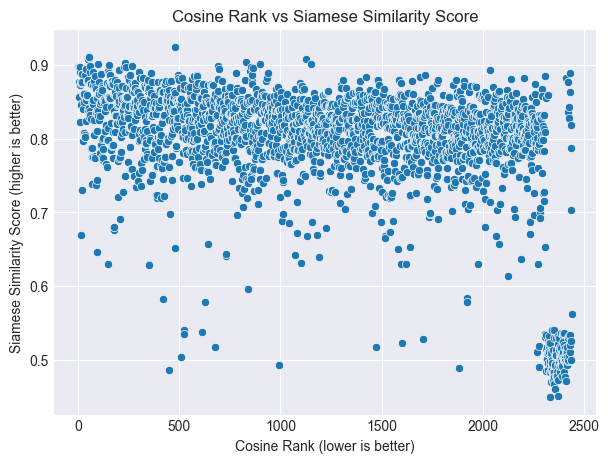

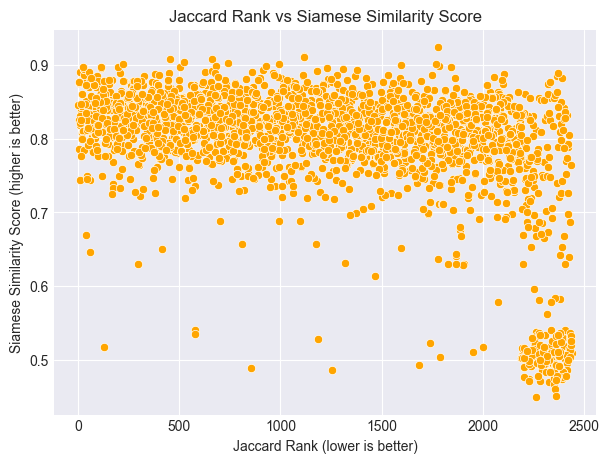

In [8]:
# Scatter plot: Cosine Rank vs Siamese Similarity
plt.figure(figsize=(7,5))
sns.scatterplot(x='Cosine_Rank', y='similarity_score', data=merged)
plt.title('Cosine Rank vs Siamese Similarity Score')
plt.xlabel('Cosine Rank (lower is better)')
plt.ylabel('Siamese Similarity Score (higher is better)')
plt.show()

# Scatter plot: Jaccard Rank vs Siamese Similarity
plt.figure(figsize=(7,5))
sns.scatterplot(x='Rank_Jaccard', y='similarity_score', data=merged, color='orange')
plt.title('Jaccard Rank vs Siamese Similarity Score')
plt.xlabel('Jaccard Rank (lower is better)')
plt.ylabel('Siamese Similarity Score (higher is better)')
plt.show()

### Inference: Scatter Plots (Cosine/Jaccard vs Siamese)

- The scatter plots show the relationship between traditional similarity ranks and Siamese similarity scores. If points are tightly clustered along a trend, the methods agree for those candidates. Outliers or a wide spread indicate candidates where the Siamese network and traditional methods disagree, possibly due to semantic features only the neural model captures.

## Rank Agreement Heatmap
We bin the ranks and similarity scores to visualize agreement.

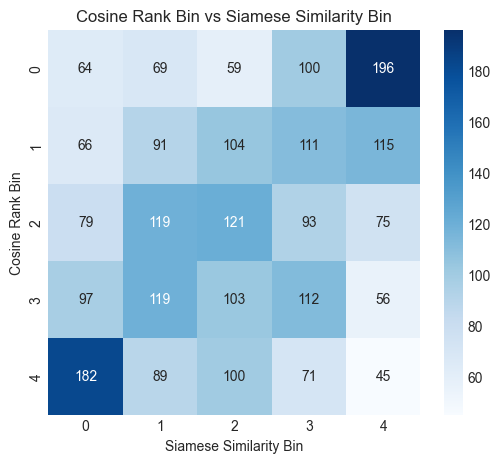

In [9]:
# Bin ranks and similarity
merged['Cosine_bin'] = pd.qcut(merged['Cosine_Rank'], 5, labels=False)
merged['Jaccard_bin'] = pd.qcut(merged['Rank_Jaccard'], 5, labels=False)
merged['Siamese_bin'] = pd.qcut(merged['similarity_score'], 5, labels=False)

# Heatmap: Cosine vs Siamese
heatmap_data = pd.crosstab(merged['Cosine_bin'], merged['Siamese_bin'])
plt.figure(figsize=(6,5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues')
plt.title('Cosine Rank Bin vs Siamese Similarity Bin')
plt.xlabel('Siamese Similarity Bin')
plt.ylabel('Cosine Rank Bin')
plt.show()

### Inference: Rank Agreement Heatmap

- The heatmap visualizes how often candidates fall into the same rank bins for Cosine and Siamese methods. A strong diagonal pattern indicates high agreement, while off-diagonal concentrations suggest systematic differences. If the heatmap is diffuse, the methods often disagree on candidate ranking.

## Top Candidates Comparison
Let's look at the top 10 candidates according to each method.

In [10]:
# Top 10 by Cosine
top_cosine = merged.nsmallest(10, 'Cosine_Rank')[['Candidate_Name', 'Cosine_Rank', 'Rank_Jaccard', 'similarity_score']]
print('Top 10 by Cosine Rank:')
display(top_cosine)

# Top 10 by Jaccard
top_jaccard = merged.nsmallest(10, 'Rank_Jaccard')[['Candidate_Name', 'Cosine_Rank', 'Rank_Jaccard', 'similarity_score']]
print('Top 10 by Jaccard Rank:')
display(top_jaccard)

# Top 10 by Siamese
top_siamese = merged.nlargest(10, 'similarity_score')[['Candidate_Name', 'Cosine_Rank', 'Rank_Jaccard', 'similarity_score']]
print('Top 10 by Siamese Similarity:')
display(top_siamese)

Top 10 by Cosine Rank:


,Candidate_Name,Cosine_Rank,Rank_Jaccard,similarity_score
0,Candidate_694,1,114,0.896963
1,Candidate_859,2,113,0.896155
2,Candidate_638,3,112,0.896411
3,Candidate_749,4,181,0.855879
4,Candidate_716,5,33,0.877292
5,Candidate_657,6,32,0.876451
6,Candidate_609,7,9,0.890213
7,Candidate_804,8,630,0.873114
8,Candidate_644,9,504,0.897640
9,Candidate_861,10,117,0.822979


Top 10 by Jaccard Rank:


,Candidate_Name,Cosine_Rank,Rank_Jaccard,similarity_score
192,Candidate_60,193,1,0.845330
123,Candidate_756,124,2,0.786315
892,Candidate_127,893,3,0.825010
14,Candidate_675,15,4,0.875704
16,Candidate_619,17,5,0.876283
15,Candidate_895,16,6,0.876957
682,Candidate_1887,683,7,0.830875
463,Candidate_1500,464,8,0.744369
6,Candidate_609,7,9,0.890213
953,Candidate_2362,955,10,0.821563


Top 10 by Siamese Similarity:


,Candidate_Name,Cosine_Rank,Rank_Jaccard,similarity_score
479,Candidate_1808,480,1777,0.924029
52,Candidate_857,53,1115,0.911410
53,Candidate_636,54,1116,0.911107
54,Candidate_692,55,1114,0.910803
1124,Candidate_1950,1126,454,0.908085
47,Candidate_798,48,662,0.907478
831,Candidate_1829,832,524,0.903648
232,Candidate_795,233,743,0.901818
1148,Candidate_1885,1150,1767,0.901131
96,Candidate_751,97,992,0.900926


### Inference: Top Candidates Comparison

- Overlap in the top 10 lists across methods indicates consensus on the best-matching candidates. If there are unique candidates in each list, it suggests that each method captures different strengths or features in the resumes. High overlap means the methods are robust and consistent for top matches.

## Inferences from Comparative Analysis

- **Correlation Results:** High Spearman correlation between Cosine and Jaccard ranks suggests these methods often agree, while lower correlation with Siamese scores indicates it captures different aspects of similarity.
- **Agreement Patterns:** Scatter plots and heatmaps reveal clusters where all methods agree, and outliers where one method strongly disagrees.
- **Top Candidates:** Overlap in top 10 lists shows consensus on best matches. Unique candidates in each list may highlight strengths of specific algorithms.
- **Outliers:** Candidates with large rank differences between methods may have features that are valued differently by each algorithm.
- **Score Distributions:** Comparing the spread of scores can show if one method is more discriminative or lenient in its matching.

In [12]:
# Find candidates with the most agreement across all three ranking techniques
# Normalize ranks: lower is better for Cosine/Jaccard, higher is better for Siamese (so invert Siamese for comparison)
merged['Siamese_Rank'] = merged['similarity_score'].rank(ascending=False, method='min')

# Calculate standard deviation of ranks for each candidate
merged['Rank_Std'] = merged[['Cosine_Rank', 'Rank_Jaccard', 'Siamese_Rank']].std(axis=1)

# Candidates with lowest std dev are most closely ranked by all three
most_agreed = merged.nsmallest(10, 'Rank_Std')[['Candidate_Name', 'Cosine_Rank', 'Rank_Jaccard', 'Siamese_Rank', 'Rank_Std']]
print('Candidates with most agreement across all three techniques:')
display(most_agreed)

Candidates with most agreement across all three techniques:


,Candidate_Name,Cosine_Rank,Rank_Jaccard,Siamese_Rank,Rank_Std
2309,Candidate_1577,2314,2309,2316.0,3.605551
2332,Candidate_1622,2337,2344,2351.0,7.000000
37,Candidate_635,38,29,24.0,7.094599
38,Candidate_856,39,27,26.0,7.234178
39,Candidate_691,40,26,27.0,7.810250
2320,Candidate_1838,2325,2341,2326.0,8.962886
2315,Candidate_1740,2320,2333,2339.0,9.712535
30,Candidate_829,31,28,47.0,10.214369
2335,Candidate_1614,2340,2340,2359.0,10.969655
1813,Candidate_1354,1816,1837,1838.0,12.423097


### Inference: Most Agreed Candidates

- The candidates with the lowest standard deviation in their ranks are those for whom all three algorithms most closely agree. These are the most robust matches, likely to be strong candidates regardless of the matching technique used.

# Conclusion
This notebook provided a comparative analysis of three resume-JD matching algorithms.

- **Cosine and Jaccard** (from ML classification) tend to agree closely, but Siamese network scores may differ.
- The correlation and visualizations help identify where the models agree and where they diverge.

You can further extend this analysis by exploring feature importances, error cases, or expert annotations.